# DATA ANALYSIS

# Lodaing dataset

In [1]:
# ==== IMPORSTS & SETTINGS ====
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# ==== FUNCTION ====
def load_csv_to_df(csv_path, sep=";"):
    try:
        df = pd.read_csv(csv_path, encoding="utf-8", sep=sep)
        print(f"Successfully loaded CSV from {csv_path}")
        print(f"DataFrame shape: {df.shape}")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading CSV from {csv_path}: {e}")
        return None

def load_parquet_to_df(parquet_path, na=False):
    try:
        df = pd.read_parquet(parquet_path)
        print(f"Successfully loaded Parquet from {parquet_path}")
        print(f"DataFrame shape: {df.shape}")
        if na:
            print(f"DataFrame N/A counts:\n{df.isna().sum()}\n")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading Parquet from {parquet_path}: {e}")
        return None

# ==== DEFINE PATHS ====
data_path = "../Data/gcp_order/dtu_findit/extraction_and_processing/"

# ==== DEFINE FILES ====
file1 = "thesis_meta_added_equations_to_olivers_26032026.parquet"
file2 = "thesis_meta_added_linguistics_to_olivers_26032026.parquet"
file3 = "thesis_meta_added_supervisors_26032026.parquet"
file4 = "thesis_meta_all_metrics_except_grade_27032026.parquet"
file5 = "thesis_meta_all_metrics_except_grade_filtered_27032026.parquet"

# ==== LOAD DATAFRAMES ====
#print("df1:")
#df1 = load_parquet_to_df(data_path + file1)
#print("df2:")
#df2 = load_parquet_to_df(data_path + file2)
#print("df3:")
#df3 = load_parquet_to_df(data_path + file3)
df_all = load_parquet_to_df(data_path + file4)
df_filtered = load_parquet_to_df(data_path + file5)

# ==== DROP NA COLUMNS ====
df_all_noNA = df_all.dropna(axis=1, how="all")
print(f"df_all_noNA shape: {df_all_noNA.shape}")
print(f"df_all_noNA columns: {df_all_noNA.columns.tolist()}\n")
df_filtered_noNA = df_filtered.dropna(axis=1, how="all")
print(f"df_filtered_noNA shape: {df_filtered_noNA.shape}")
print(f"df_filtered_noNA columns: {df_filtered_noNA.columns.tolist()}\n")

# ==== COLUMNS TO DROP ====
drop_columns = [
    "access_ss",
    "Affiliations",
    "collection_facet",
    "format",
    "fulltext_availability_facet",
    "ISBN",
    "Journal Page",
    "isolanguage_facet",
    "Publisher",
    "Source",
    "source_all_ss",
    "match_trigger",
    "equation_pipeline_version",
    "pdf_file_analysis",
    "num_tot_pages_analysis",
    "num_cont_pages_analysis",
    "num_words_full_analysis",
    "num_words_cont_analysis",
    "abstract_ts_analysis",
    "Author_analysis",
    "Publication Year_analysis",
    "primary_member_id_s_analysis",
    "Title_analysis",
    ]

# ==== DROP COLUMNS ====
df_all_noNA_clean = df_all_noNA.drop(columns=drop_columns, errors="ignore")
print(f"df_all_noNA_clean shape: {df_all_noNA_clean.shape}")
print(f"df_all_noNA_clean columns: {df_all_noNA_clean.columns.tolist()}\n")
df_filtered_noNA_clean = df_filtered_noNA.drop(columns=drop_columns, errors="ignore")
print(f"df_filtered_noNA_clean shape: {df_filtered_noNA_clean.shape}")
print(f"df_filtered_noNA_clean columns: {df_filtered_noNA_clean.columns.tolist()}\n")

# ==== LOCK DATAFRAMES FOR ANALYSIS ====
print("Final DataFrames for Analysis:")
df_all_final = df_all_noNA_clean.copy()
print(f"df_all_final shape: {df_all_final.shape}")
df_filtered_final = df_filtered_noNA_clean.copy()
print(f"df_filtered_final shape: {df_filtered_final.shape}")

Successfully loaded Parquet from ../Data/gcp_order/dtu_findit/extraction_and_processing/thesis_meta_all_metrics_except_grade_27032026.parquet
DataFrame shape: (19690, 76)
DataFrame columns: ['abstract_ts', 'access_ss', 'Affiliations', 'Timestamp', 'Author', 'citation_count_i', 'ID', 'dtu_library_collection_facet', 'collection_facet', 'Publication Year', 'Conference', 'DOI', 'Editor', 'embargo_ssf', 'format', 'fulltext_availability_facet', 'has_openaccess_fulltext_b', 'holdings_ssf', 'ISBN', 'Journal Issue', 'journal_issue_tsort', 'journal_oa_model_ss', 'Journal Page', 'journal_page_start_tsort', 'Journal Title', 'journal_title_facet', 'toc_key_s', 'Journal Volume', 'journal_vol_tsort', 'keywords_ts', 'keywords_facet', 'keywords_normalized', 'isolanguage_facet', 'member_id_ss', 'ORCID', 'primary_member_id_s', 'Publisher', 'Source', 'source_all_ss', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'YEAR', 'PUBLISHER', 'TYPES', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_wor

## Exclude rows where Publication Year is 2026?

In [2]:
choice = input("Excluded rows with Publication Year == 2026? (Y/n): ").strip().lower()

if choice == "n":
    print("Keeping rows with Publication Year == 2026.")
else:
    # drop rows that has "Publication Year" == 2026
    print("df_all_final")
    df_all_final = df_all_final[df_all_final["Publication Year"] != 2026]
    excluded_rows_all = pd.to_numeric(df_all_noNA_clean["Publication Year"], errors="coerce").eq(2026).sum()
    print(f"Number of rows dropped with Publication Year == 2026: {excluded_rows_all}")
    print(f"df_all_final shape after dropping rows with Publication Year == 2026: {df_all_final.shape}\n")
    
    print("df_filtered_final")
    df_filtered_final = df_filtered_final[df_filtered_final["Publication Year"] != 2026]
    excluded_rows_filtered = pd.to_numeric(df_filtered_noNA_clean["Publication Year"], errors="coerce").eq(2026).sum()
    print(f"Number of rows dropped with Publication Year == 2026: {excluded_rows_filtered}")
    print(f"df_filtered_final shape after dropping rows with Publication Year == 2026: {df_filtered_final.shape}")


df_all_final
Number of rows dropped with Publication Year == 2026: 6
df_all_final shape after dropping rows with Publication Year == 2026: (19684, 32)

df_filtered_final
Number of rows dropped with Publication Year == 2026: 3
df_filtered_final shape after dropping rows with Publication Year == 2026: (6251, 45)


# ANALYSIS

The DataFrames to use are:
- `df_all_final`
- `df_filtered_final`

## Serching for trends around 2023 (realaese of ChatGPT)*
*This section has been generated and notes written by Gemini.

Link to chat used:
https://gemini.google.com/share/9f9e455c59c9

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using the filtered dataset
df = df_filtered_final.copy()

### 1. General Correlation with Publication Year
This plot provides a high-level overview of which thesis metrics are most strongly associated with the passage of time.

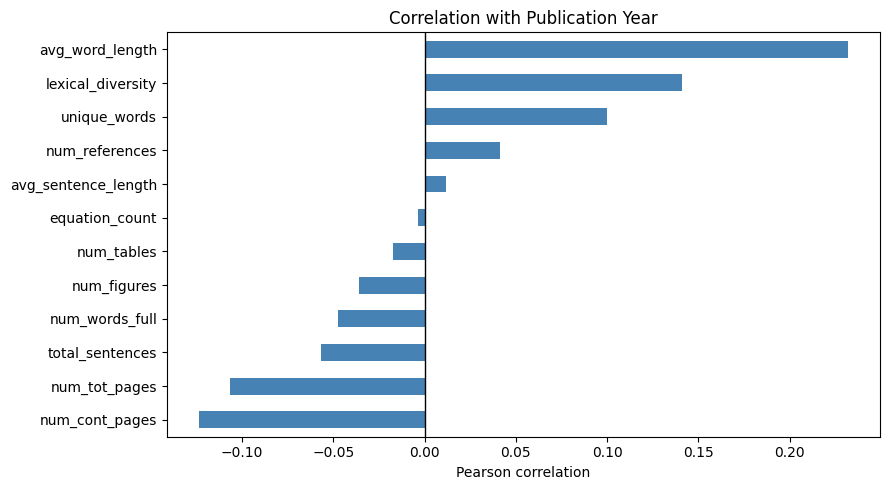

In [4]:
metrics = ["num_tot_pages", "num_cont_pages", "num_words_full", "num_figures", 
           "num_tables", "num_references", "equation_count", "total_sentences", 
           "avg_sentence_length", "unique_words", "avg_word_length", "lexical_diversity"]

corr_with_year = (
    df[["Publication Year"] + metrics]
    .dropna()
    .corr(numeric_only=True)["Publication Year"]
    .drop("Publication Year")
    .sort_values()
)

plt.figure(figsize=(9, 5))
corr_with_year.plot(kind="barh", color="steelblue")
plt.title("Correlation with Publication Year")
plt.xlabel("Pearson correlation")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

**What is seen:** There is a clear *"tug-of-war"* between physical length and linguistic complexity. Metrics like `num_cont_pages` and `num_tot_pages` show the strongest negative correlation ($r≈−0.12$), while `avg_word_length` and `lexical_diversity` show the strongest positive correlations.

**Insight:** This suggests that as years pass, theses are becoming shorter in volume but more technically *"dense"*.

### 2. The Median Complexity Spike
Using medians is more robust than averages as it prevents the 500-page *"outlier"* theses from skewing the results. This plot tracks the two most important linguistic metrics.

--- Median Metrics per Year ---
   Publication Year  num_tot_pages  lexical_diversity  avg_word_length  \
0              2019           93.0              0.134            4.805   
1              2020           93.0              0.136            4.860   
2              2021           84.0              0.137            4.900   
3              2022           79.5              0.141            4.900   
4              2023           80.0              0.142            4.980   
5              2024           83.0              0.145            5.030   
6              2025           78.0              0.158            5.200   

   num_references  
0            34.0  
1            39.0  
2            39.0  
3            42.0  
4            40.0  
5            42.0  
6            42.0  


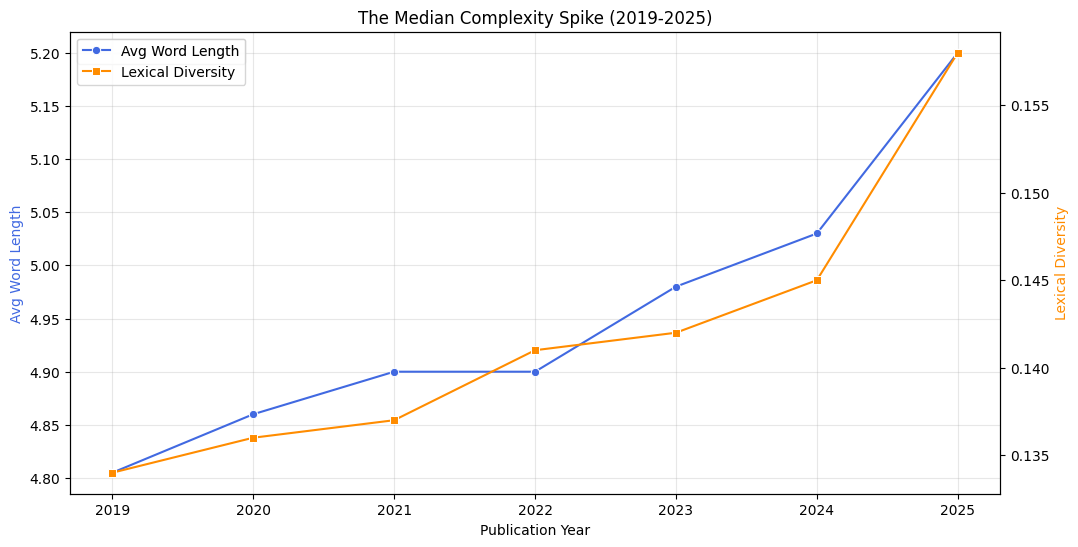

In [5]:
# 1. Calculate the Median Trends
# This is more robust against the 500-page "outliers"
median_trends = df_filtered_final.groupby('Publication Year').agg({
    'num_tot_pages': 'median',
    'lexical_diversity': 'median',
    'avg_word_length': 'median',
    'num_references': 'median'
}).reset_index()

print("--- Median Metrics per Year ---")
print(median_trends)

# Melt the median dataframe for easy plotting with Seaborn
median_melted = median_trends.melt(id_vars='Publication Year', 
                                   value_vars=['lexical_diversity', 'avg_word_length'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Word Length on primary Y-axis
sns.lineplot(data=median_trends, x='Publication Year', y='avg_word_length', 
             marker='o', color='royalblue', label='Avg Word Length', ax=ax1)
ax1.set_ylabel('Avg Word Length', color='royalblue')

# Create a second Y-axis for Lexical Diversity
ax2 = ax1.twinx()
sns.lineplot(data=median_trends, x='Publication Year', y='lexical_diversity', 
             marker='s', color='darkorange', label='Lexical Diversity', ax=ax2)
ax2.set_ylabel('Lexical Diversity', color='darkorange')

# Move legend to bottom-right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('The Median Complexity Spike (2019-2025)')
ax1.grid(True, alpha=0.3)
plt.show()

**What is seen:** A distinct *"hockey-stick"* growth pattern emerges after 2023. While word length and diversity were increasing slowly from 2019 to 2022, the slope steepens dramatically in 2024 and 2025.

**Insight:** The jump in median `avg_word_length` from $4.98$ (2023) to $5.20$ (2025) is a classic indicator of AI-assisted editing or drafting, where simpler vocabulary is replaced with more formal, academic, or *"complex"* terms.

### 3. The Concentration Shift: Pre- vs. Post-LLM Era
To see the *"regime change"* clearly, we group the data into two eras: before and after the mainstream adoption of ChatGPT and similar tools (***Pre-LLM*** and ***Post_LLM***).

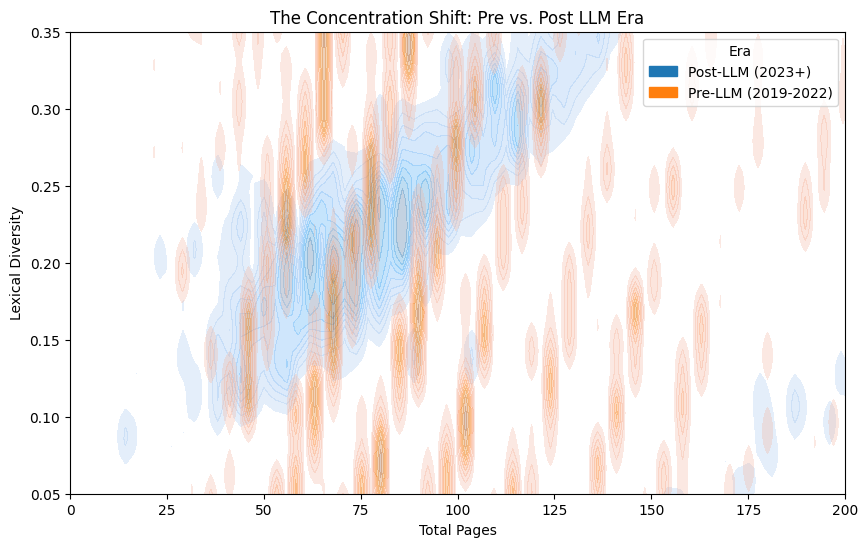

In [6]:
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM (2019-2022)'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='num_tot_pages', y='lexical_diversity', hue='Era', 
            fill=True, alpha=0.3, common_norm=False)
plt.xlim(0, 200)
plt.ylim(0.05, 0.35)
plt.title('The Concentration Shift: Pre vs. Post LLM Era')
plt.xlabel('Total Pages')
plt.ylabel('Lexical Diversity')
plt.show()

**What is seen:** The *"heat"* (density) of the ***Post-LLM*** (2023+) era sits consistently higher on the Lexical Diversity axis than the Pre-LLM era.

**Insight:** Even when two theses have the same page count, the one written after 2023 is statistically likely to have higher vocabulary diversity. This visualizes the *"density shift"* where information is more tightly packed into the text.

### 4. Zoomed Cluster Analysis
By removing the extreme outliers (the few theses over 250 pages), we can see how the bulk of the student body has changed their writing habits.

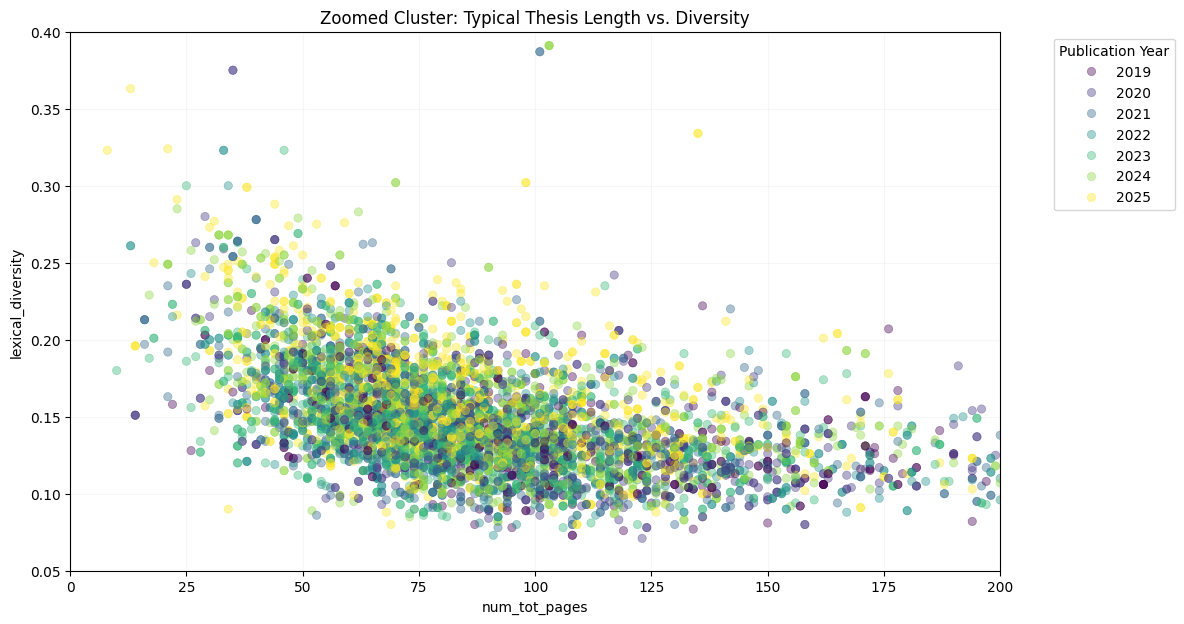

In [7]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='num_tot_pages', y='lexical_diversity', 
                hue='Publication Year', palette='viridis', alpha=0.4, edgecolor=None)
plt.xlim(0, 200)
plt.ylim(0.05, 0.4)
plt.title('Zoomed Cluster: Typical Thesis Length vs. Diversity')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.1)
plt.show()

**What is seen:** The yellow dots (2025) are visibly clustered toward the top-left of the plot (shorter length, higher diversity). The dark purple/blue dots (2019-2020) are spread more toward the bottom-right.

**Insight:** This confirms that the typical MSc thesis has migrated from a $~95$-page/$0.13$ diversity document in 2019 to a $~78$-page/$0.16$ diversity document in 2025.

### 5. Departmental Analysis
Investigating if the LLM addoptiation differe pr. department

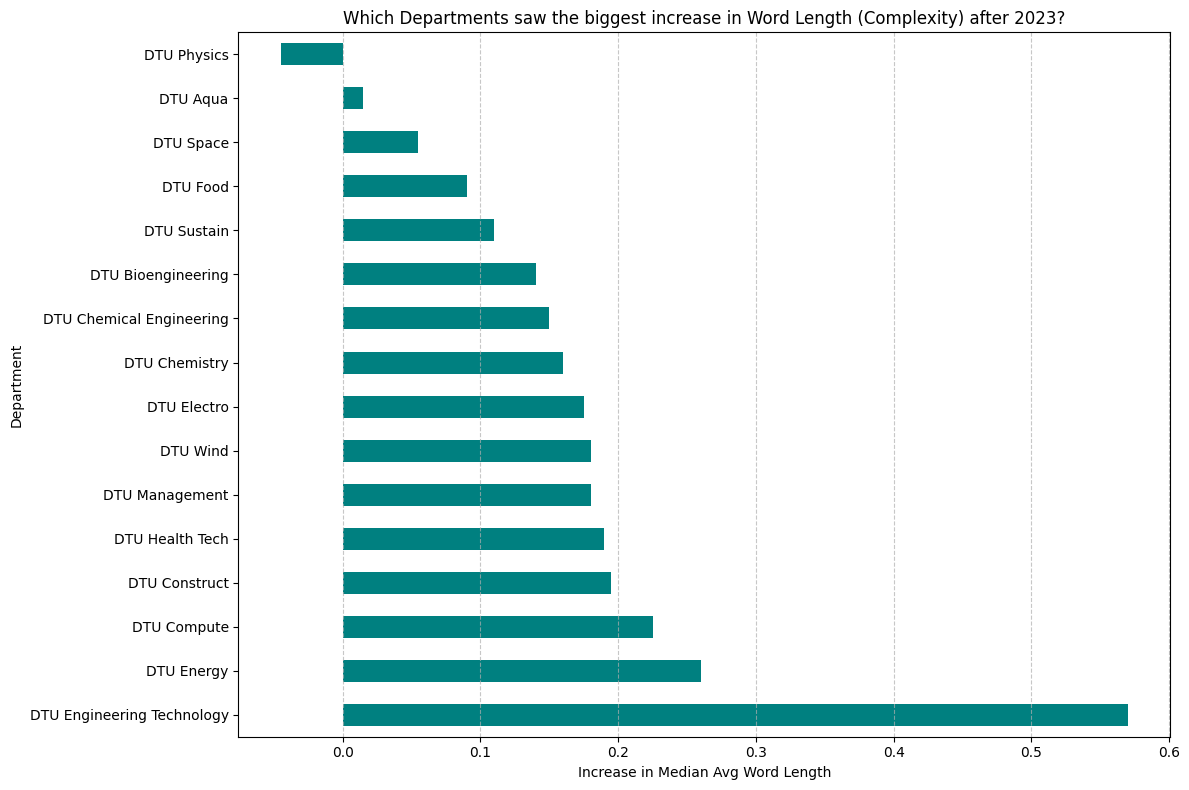

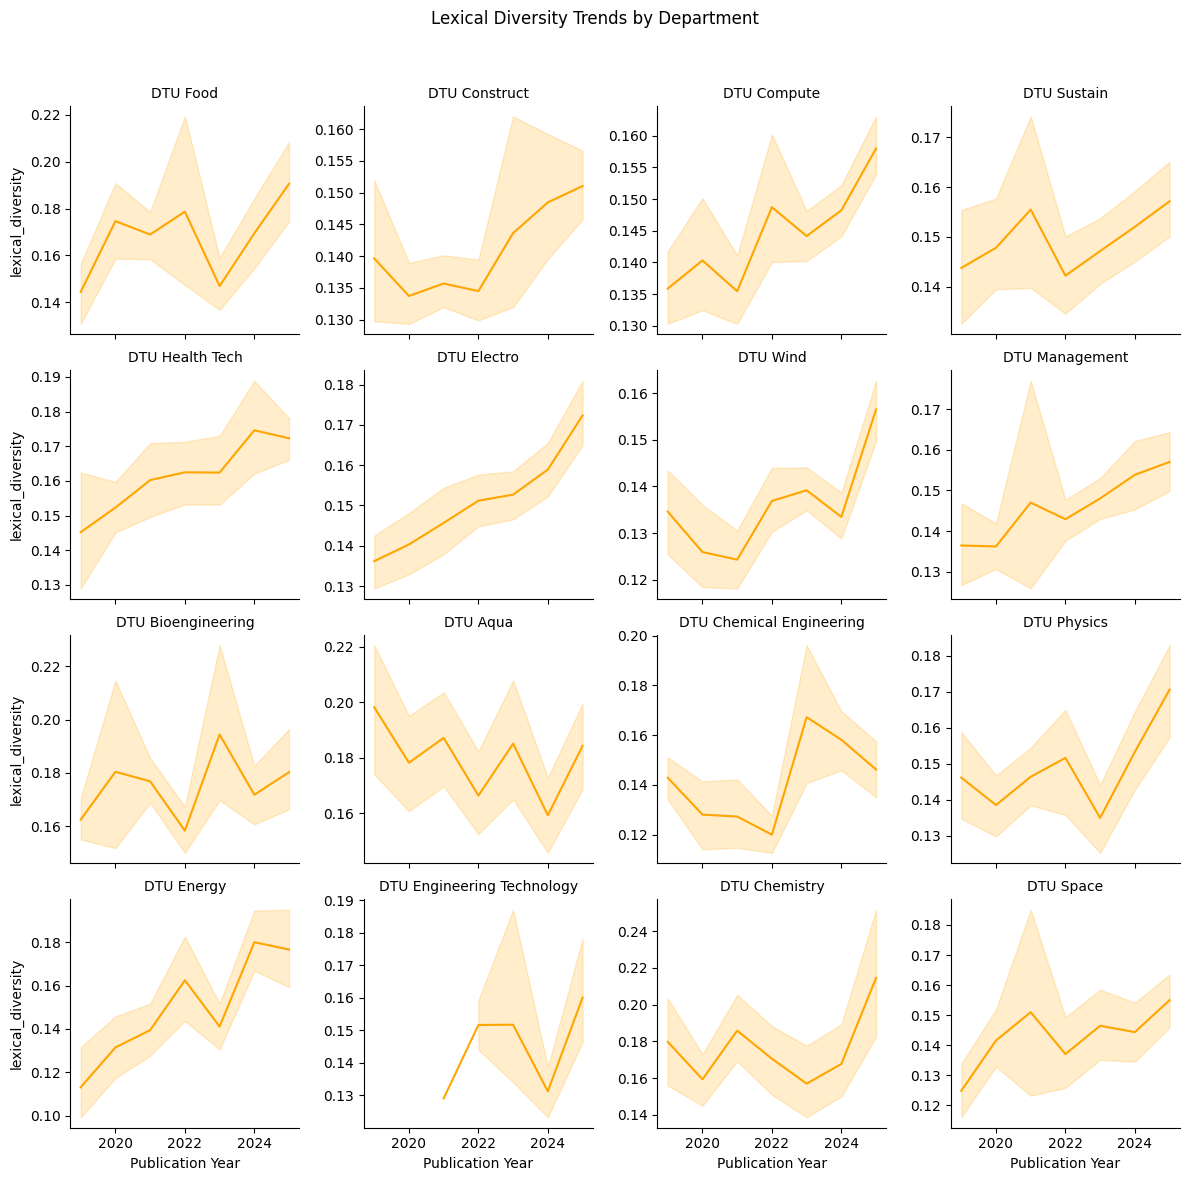

In [8]:
# 1. Calculate the 'LLM Shift' per Department
# We compare the median complexity of the 'Pre' era vs the 'Post' era
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM'
)

dept_comparison = df.groupby(['Department_new', 'Era'])['avg_word_length'].median().unstack()
dept_comparison['Shift'] = dept_comparison['Post-LLM (2023+)'] - dept_comparison['Pre-LLM']
dept_comparison = dept_comparison.sort_values('Shift', ascending=False)

# 2. Visualize the departments with the biggest "Linguistic Jump"
plt.figure(figsize=(12, 8))
dept_comparison['Shift'].plot(kind='barh', color='teal')
plt.title('Which Departments saw the biggest increase in Word Length (Complexity) after 2023?')
plt.xlabel('Increase in Median Avg Word Length')
plt.ylabel('Department')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Small Multiples (Facets) to see the trend lines per Department
# This will show you if some departments spiked while others stayed flat
g = sns.FacetGrid(df, col="Department_new", col_wrap=4, height=3, sharey=False)
g.map(sns.lineplot, "Publication Year", "lexical_diversity", color="orange")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Lexical Diversity Trends by Department')
plt.show()

--- Departments by Lexical Diversity Increase (Δ) ---
Era                         Pre-LLM  Post-LLM  Diversity_Gain_% (Δ)
Department_new                                                     
DTU Energy                   0.1310    0.1695             29.389313
DTU Chemical Engineering     0.1265    0.1470             16.205534
DTU Space                    0.1300    0.1490             14.615385
DTU Electro                  0.1400    0.1560             11.428571
DTU Management               0.1330    0.1475             10.902256
DTU Wind                     0.1260    0.1380              9.523810
DTU Compute                  0.1350    0.1470              8.888889
DTU Health Tech              0.1520    0.1640              7.894737
DTU Bioengineering           0.1640    0.1765              7.621951
DTU Construct                0.1300    0.1380              6.153846
DTU Sustain                  0.1390    0.1460              5.035971
DTU Physics                  0.1430    0.1460              2.0

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_19116/1284043529.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=era_summary.index, y='Diversity_Gain_% (Δ)', data=era_summary, palette='coolwarm')


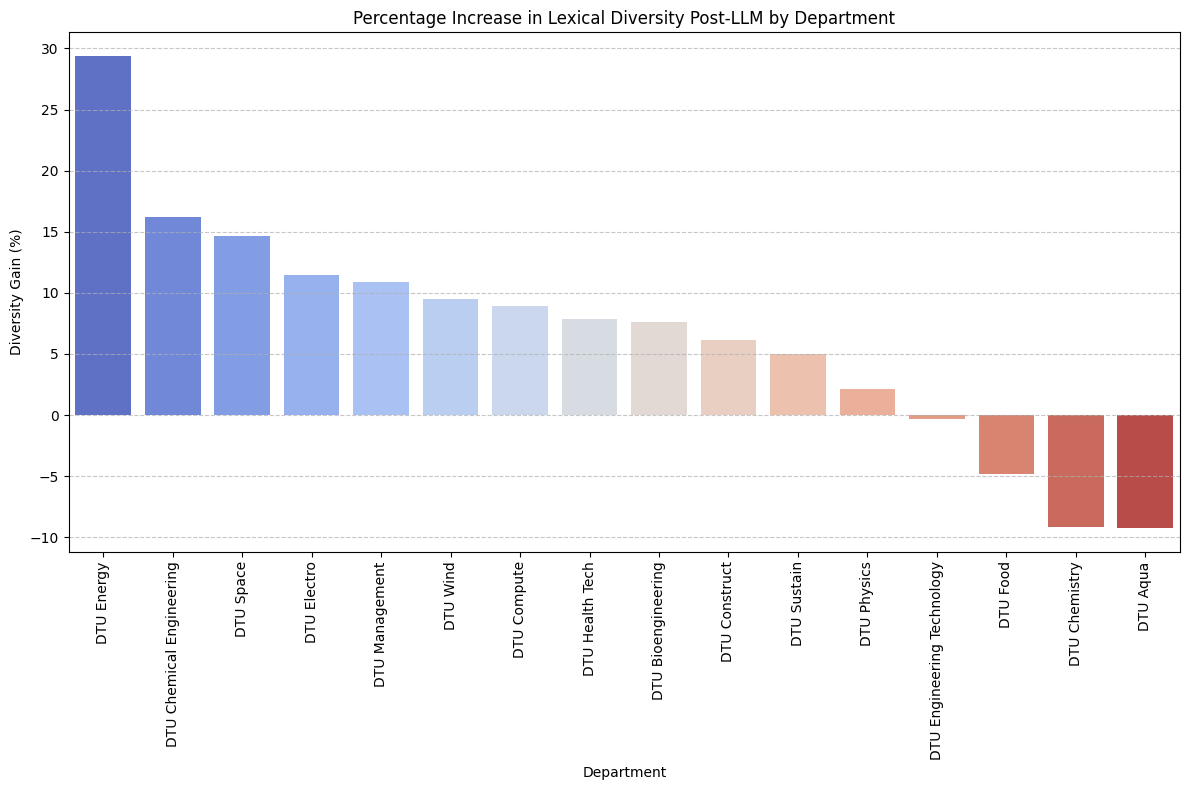

In [10]:
# 1. Ensure the Era column is defined consistently
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM' if x >= 2023 else 'Pre-LLM'
)

# 2. Pivot the data
era_summary = df.groupby(['Department_new', 'Era'])['lexical_diversity'].median().unstack()

# 3. Calculate gain using the actual column names present in the dataframe
# This avoids KeyError if the strings were slightly different
pre_col = 'Pre-LLM'
post_col = 'Post-LLM'

if pre_col in era_summary.columns and post_col in era_summary.columns:
    era_summary['Diversity_Gain_% (Δ)'] = (
        (era_summary[post_col] - era_summary[pre_col]) / era_summary[pre_col]
    ) * 100
    
    # Sort and show results
    era_summary = era_summary.sort_values('Diversity_Gain_% (Δ)', ascending=False)
    print("--- Departments by Lexical Diversity Increase (Δ) ---")
    print(era_summary[['Pre-LLM', 'Post-LLM', 'Diversity_Gain_% (Δ)']])
else:
    print(f"Error: Could not find columns. Available columns are: {era_summary.columns.tolist()}")


# plotting the delta
plt.figure(figsize=(12, 8))
sns.barplot(x=era_summary.index, y='Diversity_Gain_% (Δ)', data=era_summary, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Percentage Increase in Lexical Diversity Post-LLM by Department')
plt.ylabel('Diversity Gain (%)')
plt.xlabel('Department')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ARCHIVES

## LEAGACY - DEVELOPING the: "Serching for trends around 2023 (realaese of ChatGPT)"

In [ ]:
# Searching for trends around 2023 (using Publication Year)

source_df = df_filtered_final if "df_filtered_final" in globals() else df_filtered_noNA_clean

metrics = [
    "num_tot_pages",
    "num_cont_pages",
    "num_words_full",
    "num_figures",
    "num_tables",
    "num_references",
    "equation_count",
    "total_sentences",
    "avg_sentence_length",
    "unique_words",
    "avg_word_length",
    "lexical_diversity",
]

available_metrics = [m for m in metrics if m in source_df.columns]

df_plot = source_df.copy()

# Use Publication Year only
df_plot["Publication Year"] = pd.to_numeric(
    df_plot["Publication Year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

for col in available_metrics:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

df_plot = df_plot.dropna(subset=["Publication Year"])
df_plot = df_plot[(df_plot["Publication Year"] >= 2000) & (df_plot["Publication Year"] <= 2030)]

corr_with_year = (
    df_plot[["Publication Year"] + available_metrics]
    .dropna()
    .corr(numeric_only=True)["Publication Year"]
    .drop("Publication Year")
    .sort_values()
)

plt.figure(figsize=(9, 5))
corr_with_year.plot(kind="barh", color="steelblue")
plt.title("Correlation with Publication Year")
plt.xlabel("Pearson correlation")
plt.ylabel("Metric")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

yearly_means = (
    df_plot.groupby("Publication Year")[available_metrics]
    .mean(numeric_only=True)
    .sort_index()
)

n = len(available_metrics)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(available_metrics):
    axes[i].plot(yearly_means.index, yearly_means[col], marker="o", linewidth=1.5)
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Yearly Mean Trends by Publication Year", y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is df_filtered_final
df = df_filtered_final.copy()

# 1. Statistical check: Is there a negative correlation?
# This tells us if shorter documents (lower pages) have higher complexity
density_metrics = ['num_tot_pages', 'lexical_diversity', 'avg_word_length', 'num_references']
correlation_matrix = df[density_metrics].corr()

print("Correlation of metrics with Total Pages:")
print(correlation_matrix['num_tot_pages'])

# 2. Visualizing the 'Density vs. Length' tradeoff
# The regression line will show the general trend across all years
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='num_tot_pages', y='lexical_diversity', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Thesis Length vs. Lexical Diversity')
plt.xlabel('Total Pages')
plt.ylabel('Lexical Diversity')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Analyzing the trend by year (Corrected column name)
# This will show if the 2024-2025 points are moving to the "High Diversity/Low Page" zone
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis'
)
plt.title('Evolution of Length and Diversity by Year')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Final confirmation of the "2023 Shift"
yearly_summary = df.groupby('Publication Year').agg({
    'num_tot_pages': 'mean',
    'lexical_diversity': 'mean',
    'avg_word_length': 'mean'
}).reset_index()

print("\nYearly Mean Trends:")
print(yearly_summary)

In [ ]:
# 1. Zooming in on the dense area
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis',
    alpha=0.5,     # Makes points transparent so you can see density
    edgecolor=None # Removes white borders around points for clarity
)

# Strategic limits based on your previous plot
plt.xlim(0, 250)  
plt.ylim(0, 0.5)  

plt.title('Zoomed View: Thesis Length vs. Diversity (0-250 Pages)')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

# 2. The "Before vs After" Comparison (The 'LLM Effect' Plot)
df_filtered_final['Era'] = df_filtered_final['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Era', 
    fill=True, 
    alpha=0.4
)
plt.title('Density Shift: Pre-LLM vs. Post-LLM Eras')
plt.xlim(0, 250)
plt.ylim(0, 0.4)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Median Trends
# This is more robust against the 500-page "outliers"
median_trends = df_filtered_final.groupby('Publication Year').agg({
    'num_tot_pages': 'median',
    'lexical_diversity': 'median',
    'avg_word_length': 'median',
    'num_references': 'median'
}).reset_index()

print("--- Median Metrics per Year ---")
print(median_trends)

# 2. Zoomed-In Scatter Plot
# We limit the axes to where 95% of the data lives (0-200 pages, 0.1-0.4 diversity)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis',
    alpha=0.4,     # High transparency to see where points stack up
    edgecolor=None
)

plt.xlim(0, 200)   # Zooming in on the X-axis
plt.ylim(0.05, 0.4) # Zooming in on the Y-axis
plt.title('Zoomed Cluster: Typical Thesis Length vs. Diversity')
plt.grid(True, alpha=0.1)
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. The "Era Shift" Density Plot
# This turns the "muddy" dots into a heatmap of concentration
df_filtered_final['Era'] = df_filtered_final['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM (2019-2022)'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Era', 
    fill=True, 
    alpha=0.3,
    common_norm=False # This ensures each era is normalized independently
)

plt.xlim(0, 200)
plt.ylim(0.05, 0.35)
plt.title('The Concentration Shift: Pre vs. Post LLM Era')
plt.xlabel('Total Pages (Median)')
plt.ylabel('Lexical Diversity (Median)')
plt.show()

In [ ]:
# Melt the median dataframe for easy plotting with Seaborn
median_melted = median_trends.melt(id_vars='Publication Year', 
                                   value_vars=['lexical_diversity', 'avg_word_length'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Word Length on primary Y-axis
sns.lineplot(data=median_trends, x='Publication Year', y='avg_word_length', 
             marker='o', color='royalblue', label='Avg Word Length', ax=ax1)
ax1.set_ylabel('Avg Word Length', color='royalblue')

# Create a second Y-axis for Lexical Diversity
ax2 = ax1.twinx()
sns.lineplot(data=median_trends, x='Publication Year', y='lexical_diversity', 
             marker='s', color='darkorange', label='Lexical Diversity', ax=ax2)
ax2.set_ylabel('Lexical Diversity', color='darkorange')

# Move legend to bottom-right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('The Median Complexity Spike (2019-2025)')
ax1.grid(True, alpha=0.3)
plt.show()

## NEW LEGACY thign